-----
# AM10 - Module: Elementary 

## Section 06
-----

### Learning objectives:

- Implementing Newton-Raphson's method for finding roots

- Applications of finding roots of known functions 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Implementing Newton-Raphson's method

In the lecture you were introduced to Newton-Raphson's method for finding roots in a given interval. In the exercises below we will again write functions for implementing this method. We will also generalize the function so that the derivative required in this method is also computed numerically. 

We have seen how to calculate derivatives numerically in the previous week. So, let's use that knowledge to write a function that calculates the first derivative using the central difference formula at a given point.

In [2]:
def dfdx(f, x0):
    
    ''' This function calculates the first derivative of a function at a given point using
        the central difference formula
        Input:
           f : A python function that defines a given mathematical function whose derivative is desired [func]
           x0 : The value at which the derivative needs to be calculated [scalar]
        Output: 
           dfdx : value of the derivative [scalar] 
    '''
    
    dx = 1e-7  # define a small dx
    dfdx = (f(x0 + dx) - f(x0 - dx)) / (2 * dx)  # central difference 
    return dfdx

For Newton-Raphson, as you might remember from the Lecture, we need to provide a trial root to start the iteration process. In the lecture exercise, we used one of the brackets as the trial root. We can do the same here. We can use the `bracketing_method` function that we wrote in the Lab 06 to do this.

In [3]:
def bracketing_method(x, fx):
    
    ''' This function can bracket the roots of a given known or unknown function
        Input:
           x : Discretized independant variable [array]
           fx : Discretized function [array]
        Output: 
           xa : left bracket [list] 
           xb : right bracket [list]
           nr : number of roots [scalar]
    '''
    
    nr = 0  # initialize number of roots
    xa = []  # initialize list to hold left brackets
    xb = []  # initialize list to hold right brackets
    for i in range(len(x) - 1):  # run loop for all elements of x but last 
        fprod = fx[i] * fx[i+1]  
        if fprod < 0:  # check sign for zero-crossing
            xa.append(x[i])
            xb.append(x[i+1])
            nr = nr + 1
    print('Number of Roots =', nr)
    print('Brackets:')
    for i in range(nr):
        print(xa[i], xb[i])
    return xa, xb, nr

Ok, now we have some of the bits and pieces that are needed for implementing Newton-Raphson. So, let's get started.

### Exercise 1

Complete the code below to write a function, `newton_raphson`, to find the roots of any given mathematical function using Newton-Raphson's method. The input arguments for this function should be 

1. a python function representing the mathematical function whose roots are desired
2. the intial guess, `xtry`, for the root
3. the convergence tolerance value at which the iterations should stop. 

`newton_raphson` should return the value of the root obtained and the number of iterations performed to find each of the roots. Make sure to safeguard against very slowly converging or non-converging cases using a condition for maximum number of iterations. Also, safeguard against a situation where the first derivative might vanish, i.e., $df/dx = 0$, by using an `if` statement.

In [4]:
def newton_raphson(f, xtry, toler):
    
    ''' This function can find the roots of a given known or unknown function
        Input:
           f : Python function representing the mathematical function whose roots are desired [func]
           xtry : Initial guess for the root [scalar]
           toler : Tolerance for convergance [scalar]
        Output: 
           xroot : value of root [scalar] 
           num_iter : number of iterations to convergence [scalar]
    '''
    
    max_iter = 500  # maximum number of iterations before exiting the function
    ferror = np.absolute(f(xtry))  # error at the initial guess
    num_iter = 0  # initializing number of iterations
    
    while ferror > toler:  # run loop until convergence to the tolerance value
        if num_iter < max_iter:  # check whether maximum iterations have reached
            df = dfdx(f, xtry)  # call function to compute derivative 
            if np.absolute(df) > 0:  # check whether derivative is zero to avoid divide-by-zero error
                xroot = xtry - f(xtry) / df  # Newton-Raphson update
                ferror = np.absolute(f(xroot))  # current error at new guess
                xtry = xroot  # make new guess the current guess
                num_iter = num_iter + 1  # update number of iterations
            else:
                print('First derivative vanishing')
                break
        else:
            print('Maximum iterations reached without convergance. Exiting loop.')
            break
    return xroot, num_iter

## Finding roots of functions using Newton-Raphson

It's time to test how well our `newton_raphson` function works. Let's first start by finding roots of the two functions from Lab 06

### Exercise 2

Complete the code below to test `newton_raphson` and find the roots of the functions $f(x)$ and $g(x)$ (from Lab 06) and also copied below. Use the left brackets as the initial guesses or trial root. Feel free to borrow code from previous Labs as you see fit.

\begin{equation}
f(x) = (x-1)(x-2)(x-3)(x-4)
\end{equation}

\begin{equation}
g(x) = \sin{x} - \frac{x}{2}
\end{equation}

In [5]:
# define fofx
def fofx(x):
    y = (x - 1)*(x - 2)*(x - 3)*(x - 4)
    return y

In [6]:
# define gofx
def gofx(x):
    y = np.sin(x) - x / 2
    return y

In [7]:
# define tolerance value
toler = 1e-9

# find brackets
nx = 40  # define number of points 
xmin = 0  # define range min
xmax = 5  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
fx = fofx(x)  # generate the array for the discretized function
xa1, xb1, nr1 = bracketing_method(x, fx)

# finding roots of fofx using Newton-Raphson
for i in range(nr1):
    xtry = xa1[i]  # use left bracket as trial root
    xroot, num_iter = newton_raphson(fofx, xtry, toler)
    print('Root', i+1, ':', xroot, ',', 'Iterations:', num_iter)

Number of Roots = 4
Brackets:
0.8974358974358974 1.0256410256410255
1.923076923076923 2.051282051282051
2.9487179487179485 3.0769230769230766
3.974358974358974 4.102564102564102
Root 1 : 0.9999999999998246 , Iterations: 4
Root 2 : 1.9999999999984475 , Iterations: 3
Root 3 : 3.00000000000096 , Iterations: 3
Root 4 : 4.000000000016994 , Iterations: 3


In [8]:
# define tolerance value
toler = 1e-9

# find brackets
nx = 40  # define number of points 
xmin = -np.pi  # define range min
xmax = np.pi  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
gx = gofx(x)  # generate the array for the discretized function
xa2, xb2, nr2 = bracketing_method(x, gx)

# finding roots of gofx using Newton-Raphson
for i in range(nr2):
    xtry = xa2[i]
    xroot, num_iter = newton_raphson(gofx, xtry, toler)
    print('Root', i+1, ':', xroot, ',', 'Iterations:', num_iter)

Number of Roots = 3
Brackets:
-2.0138414446088415 -1.8527341290401345
-0.08055365778435375 0.0805536577843533
1.852734129040134 2.0138414446088415
Root 1 : -1.895494267472813 , Iterations: 3
Root 2 : -2.8710048444527403e-11 , Iterations: 2
Root 3 : 1.8954942670342891 , Iterations: 3


### Roots of the sinc function


In the exercises below, let's apply `newton-raphson` to find roots of the function below.

\begin{equation}
j_0(x) = \frac{\sin{x}}{x}
\end{equation}

*Note:* The function described above is known as the sinc function. It should be clear from looking at the expression that this function is not defined at $x=0$. 

### Exercise 3

Create a Python function that returns the values of the sinc function described above. Call the function `j0x`. 

In [12]:
def j0x(x):
    y = np.sin(x) / x
    return y

### Exercise 4

Bracket the roots of the sinc function in the range $1 \le x \le 20$. Plot the function along with the bracketed roots in the given interval in the same figure.

Number of Roots = 6
Brackets:
2.948717948717949 3.4358974358974357
5.871794871794871 6.358974358974359
9.282051282051281 9.769230769230768
12.205128205128204 12.692307692307692
15.615384615384615 16.102564102564102
18.538461538461537 19.025641025641026


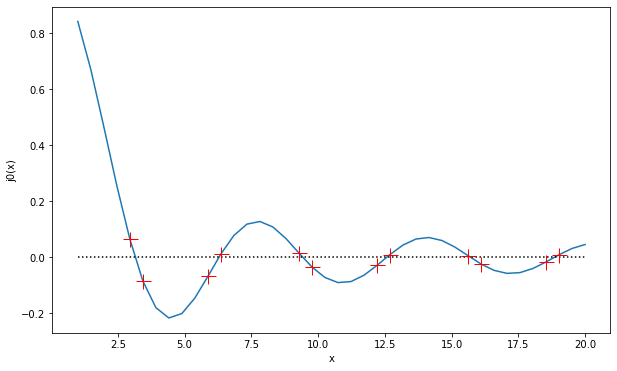

In [13]:
nx = 40  # define number of points 
xmin = 1  # define range min
xmax = 20  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
fx = j0x(x)  # generate the array for the discretized function

# call bracketing_method
xa3, xb3, nr3 = bracketing_method(x, fx)

# Plot j0ofx and the brackets
fig1, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(x, fx)
ax1.plot([xmin, xmax], [0, 0], 'k:')
for i in range(nr3):
    ax1.plot(xa3[i], j0x(xa3[i]), 'r+', markersize=15)
    ax1.plot(xb3[i], j0x(xb3[i]), 'r+', markersize=15)
ax1.set_xlabel('x')
ax1.set_ylabel('j0(x)')
plt.show(fig1)

In [14]:
# find roots
for i in range(nr3):
    xtry = xa3[i]
    xroot3, num_iter3 = newton_raphson(j0x, xtry, toler)
    print('Root', i+1, ':', xroot3, '.', 'Iterations:', num_iter3)

Root 1 : 3.141592653309593 . Iterations: 3
Root 2 : 6.28318530717651 . Iterations: 3
Root 3 : 9.424777960769378 . Iterations: 3
Root 4 : 12.56637061435879 . Iterations: 3
Root 5 : 15.707963262846796 . Iterations: 2
Root 6 : 18.84955592153865 . Iterations: 3
